In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("data/Walmart Dataset.csv", encoding="latin1")

In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9971 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [25]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
missing_df = missing_df[missing_df["Missing Count"] > 0]
print(missing_df)

           Missing Count  Missing %
Ship Mode             23       0.23
Discount              49       0.49


In [26]:
ship_mode_fill = df["Ship Mode"].mode()[0]
df["Ship Mode"].fillna(ship_mode_fill, inplace=True)

mediamofdiscount = df["Discount"].median()
df["Discount"].fillna(mediamofdiscount, inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_2500\3112550415.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Ship Mode"].fillna(ship_mode_fill, inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_2500\3112550415.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [27]:
print("Remaining nulls:", df.isnull().sum().sum())

Remaining nulls: 0


In [28]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [29]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [30]:
columns_to_drop = [
    'Row ID',
    'Order ID', 'Customer ID', 'Customer Name',
    'Product ID', 'Product Name', 'Postal Code', 'Ship Date'
]

df = df.drop(columns=columns_to_drop, axis=1)

In [31]:
columns_to_drop = [
    'Country'
]

df = df.drop(columns=columns_to_drop, axis=1)

In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    9994 non-null   datetime64[ns]
 1   Ship Mode     9994 non-null   object        
 2   Segment       9994 non-null   object        
 3   City          9994 non-null   object        
 4   State         9994 non-null   object        
 5   Region        9994 non-null   object        
 6   Category      9994 non-null   object        
 7   Sub-Category  9994 non-null   object        
 8   Sales         9994 non-null   float64       
 9   Quantity      9994 non-null   int64         
 10  Discount      9994 non-null   float64       
 11  Profit        9994 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 937.1+ KB
None


In [33]:
print(df['Discount'].unique().tolist())
print(df['Discount'].nunique())
print(df['Discount'].value_counts())

[0.0, 0.45, 0.2, 0.8, 0.3, 0.5, 0.7, 0.6, 0.32, 0.1, 0.4, 0.15]
12
Discount
0.00    4749
0.20    3706
0.70     418
0.80     300
0.30     227
0.40     206
0.60     138
0.10      94
0.50      66
0.15      52
0.32      27
0.45      11
Name: count, dtype: int64


In [34]:
import pandas as pd

# Define the bin edges: [-0.01 to 0.0], [0.0 to 0.20], [0.20 to 0.50], [0.50 to 1.0]
bins = [-0.01, 0.0, 0.2, 0.5, 1.0]

labels = ['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']

df['Discount_Category'] = pd.cut(df['Discount'], bins=bins, labels=labels)

print(df[['Discount', 'Discount_Category']].head(10))

   Discount Discount_Category
0      0.00       No Discount
1      0.00       No Discount
2      0.00       No Discount
3      0.45   Medium Discount
4      0.20      Low Discount
5      0.00       No Discount
6      0.20      Low Discount
7      0.20      Low Discount
8      0.20      Low Discount
9      0.00       No Discount


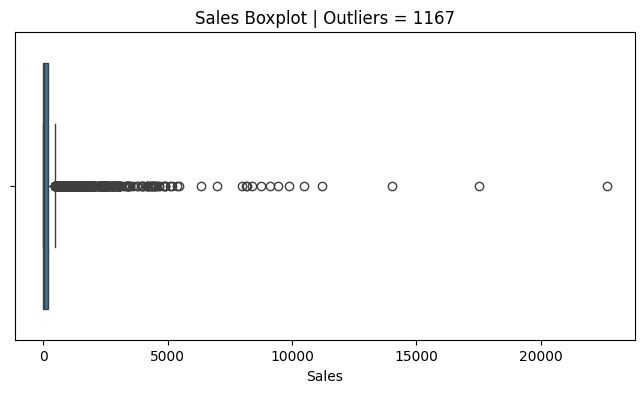

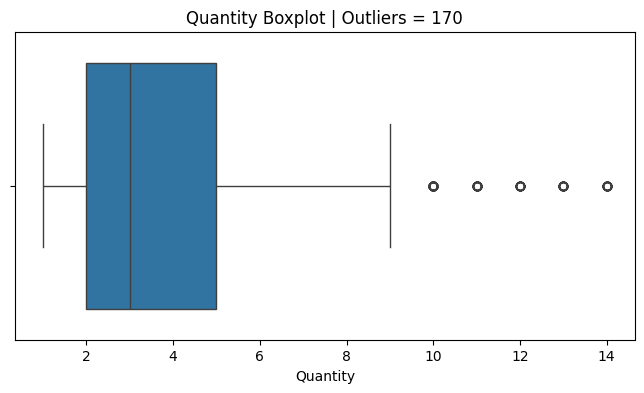

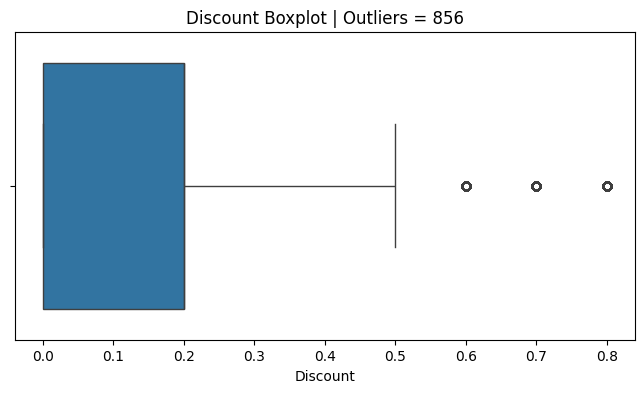

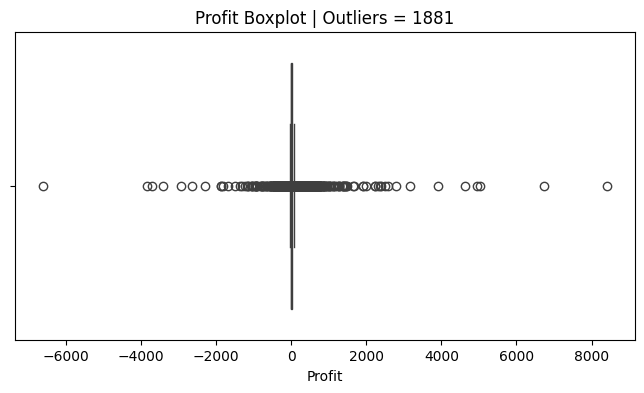

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create boxplots for every numeric column
for col in numeric_cols:

    # Calculate IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Outlier limits
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    count = outliers.shape[0]

    # Plot
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])

    plt.title(f"{col} Boxplot | Outliers = {count}")
    plt.xlabel(col)
    plt.show()

In [36]:
df["Sales_Original"] = df["Sales"]
df["Sales_Log"] = np.log1p(df["Sales"])
df.drop(columns=["Sales"], inplace=True)

Number of outliers in Sales_Log: 10
Lower Bound: -0.7628416842076922
Upper Bound: 9.020222983082164
      Sales_Original  Sales_Log
2623       11199.968   9.323755
2697       22638.480  10.027451
4098        9449.950   9.153871
4190       10499.970   9.259223
4277        9099.930   9.116132


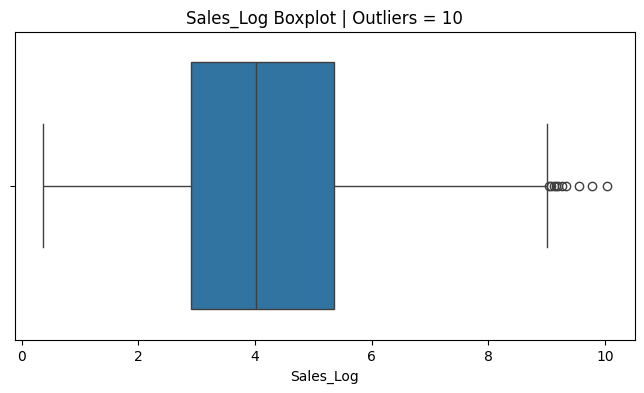

In [37]:
Q1 = df["Sales_Log"].quantile(0.25)
Q3 = df["Sales_Log"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Outliers rows
outliers = df[(df["Sales_Log"] < lower) | (df["Sales_Log"] > upper)]

# Count
print("Number of outliers in Sales_Log:", outliers.shape[0])

# Show limits
print("Lower Bound:", lower)
print("Upper Bound:", upper)

# Show some outliers
print(outliers[["Sales_Original", "Sales_Log"]].head())

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Sales_Log"])
plt.title(f"Sales_Log Boxplot | Outliers = {outliers.shape[0]}")
plt.show()

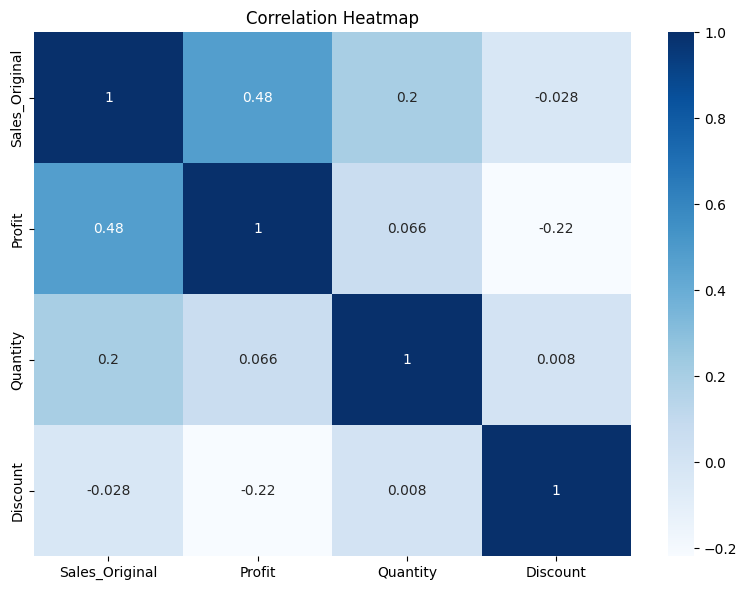

In [38]:
corr_cols = [
    "Sales_Original",
    "Profit",
    "Quantity",
    "Discount",
]
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [39]:
cols_to_cap = ['Quantity']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

In [40]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 1
Duplicate rows: 0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order Date         9993 non-null   datetime64[ns]
 1   Ship Mode          9993 non-null   object        
 2   Segment            9993 non-null   object        
 3   City               9993 non-null   object        
 4   State              9993 non-null   object        
 5   Region             9993 non-null   object        
 6   Category           9993 non-null   object        
 7   Sub-Category       9993 non-null   object        
 8   Quantity           9993 non-null   float64       
 9   Discount           9993 non-null   float64       
 10  Profit             9993 non-null   float64       
 11  Discount_Category  9993 non-null   category      
 12  Sales_Original     9993 non-null   float64       
 13  Sales_Log          9993 non-null   float64       
dtypes: category(1

***

### Current State of the Dataset

The dataset is now clean, free of missing values, and the outliers have been handled appropriately. 

You will notice that some columns were **not dropped** and we have variations of the same feature (e.g., `Sales` and `Sales_Log`). This is intentional to serve both the **PowerBI/EDA** and the **Machine Learning**.

Here is the breakdown of how to use the current columns:

#### 1. For Exploratory Data Analysis (EDA) & PowerBI
If you are working on creating the dashboard or extracting business insights, please use the **Original Columns**:
* `Sales`, `Profit`, `Discount`, `Quantity`: These represent the actual business figures and are essential for accurate financial reporting.
* `Order Date`: Required for the Time Series analysis.
* **Note:** Do not use the Log or Categorical versions of these columns for visualizations, as the business owners need to see the real monetary values.

####  2. For Machine Learning
If you are working on the predictive model (Step 5), you must use the **Engineered Columns** to ensure high accuracy and avoid errors:
* Use `Sales_Log` instead of `Sales` (Target Variable - Log transformation handles extreme values).
* Use `Discount_Category` instead of `Discount` (Binning improves model understanding of clearance events).
* The `Quantity` column have already been capped (Winsorized) to handle extreme outliers safely without dropping customer records.

#### Action Required Before Training the Model:
Before feeding this DataFrame into any Machine Learning algorithm, the ML team needs to create a new dataframe (e.g., `ml_df`) and perform the following final drops:
1.  **Drop `Profit`:** (we cannot predict sales using the final profit).
2.  **Drop Originals:** Drop `Sales_Original`, `Discount`.
3.  **Apply Encoding:** Convert the remaining categorical columns (like `Category`, `Region`, `Segment`) into numerical values using One-Hot Encoding or Label Encoding.

***

In [42]:
df.to_csv('data/Walmart_Cleaned_for_BI.csv', index=False)

# Encoding

ba3den isa